In [84]:
import pandas as pd

In [85]:
data = pd.read_csv('C:\\Users\\DELL\\OneDrive\\Desktop\\bastion_lab\\python_learning\\datasets\\Crop_recommendation.csv')
data.head()





,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [86]:
X = data.drop("label", axis = 1)
y = data["label"]

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42 ) 





In [87]:
# ENTRAINEMENT DU MODELE

# 1. DECISION TREE

from sklearn.tree import DecisionTreeClassifier



model = DecisionTreeClassifier()
model.fit(X_train, y_train)
model.score(X_test, y_test)





0.9886363636363636

In [88]:
# EVALUATION DU MODELE
# 1. ACCURACY



from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy decision tree:", accuracy)




Accuracy decision tree: 0.9886363636363636


matrice de confusion : 
 [[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  1  0  0 22  0  0  0  0  0  0  0  0]
 [ 0  0  

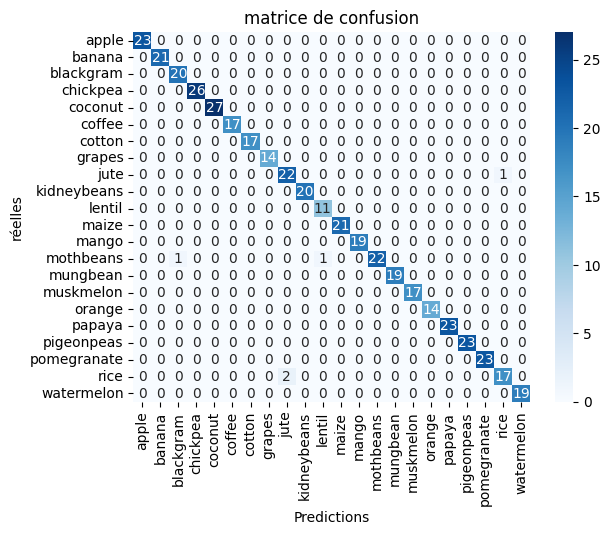

In [89]:
# 2. Matrice de confusion


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("matrice de confusion : \n", cm)



# ajouter des étiquettes pour une meilleure lisibilité et nom des classes
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predictions')
plt.ylabel('réelles')
plt.title('matrice de confusion')
plt.show()




In [90]:

# KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy KNN:", accuracy_knn)




Accuracy KNN: 0.9704545454545455


In [91]:
# NORMALISATION DES DONNEES (mettre toutes les variables à la meme échelle)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)






In [92]:
# re-entrainement du modèle avec les données normalisées

knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(X_train_scaled, y_train)

y_pred_knn_scaled = knn.predict(X_test_scaled)


accuracy_knn_scaled = accuracy_score(y_test, y_pred_knn_scaled)

print("Accuracy KNN(scaled) : ", accuracy_knn_scaled)




Accuracy KNN(scaled) :  0.9568181818181818


[0.9636363636363636, 0.9590909090909091, 0.9681818181818181, 0.9568181818181818, 0.9568181818181818, 0.9613636363636363, 0.9590909090909091, 0.95, 0.9522727272727273, 0.95, 0.9386363636363636, 0.9409090909090909, 0.9340909090909091, 0.9318181818181818, 0.9340909090909091, 0.9295454545454546, 0.9272727272727272, 0.925, 0.9272727272727272, 0.9272727272727272]


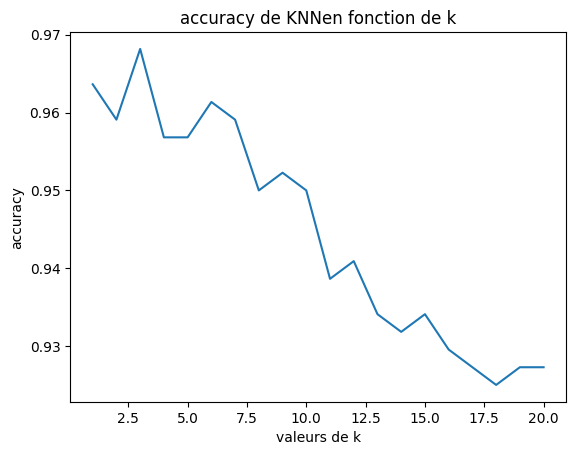

In [93]:
# plusierus valeurs de k pour trouver la meilleure

valeurs_k = range(1,21)
accuracies = []

for i in valeurs_k: 
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test,y_pred)
    accuracies.append(accuracy)
print(accuracies)
 
plt.plot(valeurs_k, accuracies)
plt.xlabel('valeurs de k')
plt.ylabel('accuracy')
plt.title('accuracy de KNNen fonction de k')
plt.show()





In [94]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest:", accuracy_rf)




Accuracy Random Forest: 0.9931818181818182


In [95]:
k = range(10, 200, 10)
accuracies_rf = []

for i in k:
    rf = RandomForestClassifier(n_estimators = i, random_state = 42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    accuracies_rf.append(accuracy_rf)
print(accuracies_rf)

[0.9863636363636363, 0.990909090909091, 0.990909090909091, 0.990909090909091, 0.990909090909091, 0.990909090909091, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182, 0.9931818181818182]


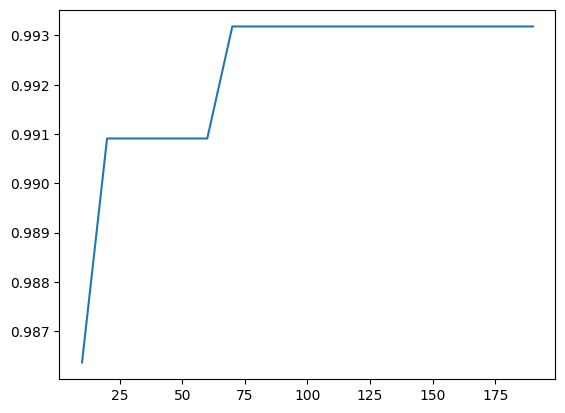

In [96]:

plt.plot(k, accuracies_rf)